## Preguntas
* ¿Cuál es el costo médico típico de una persona asegurada?

* ¿qué nos dicen estos datos sobre los costos médicos?

* ¿qué decisiones podría tomar una aseguradora con esta información?

* ¿ qué riesgos habría si solo miramos el promedio?

In [1]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("insurance.csv")


In [11]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
df.coldesumns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
print(df.isnull().sum())


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [14]:
grupo_region = df.groupby("region")
grupo_region

In [ ]:
resumen_promedios_por_region = df.groupby("region").agg(
    edad_promedio=("age", "mean"),
    bmi_promedio=("bmi", "mean"),
    cargos_promedio=("charges", "mean"),
    cargos_total=("charges", "sum"),
    cantidad=("charges", "count")
).round(2)

resumen_promedios_por_region

,edad_promedio,bmi_promedio,cargos_promedio,cargos_total,cantidad
region,,,,,
northeast,39.27,29.17,13406.38,4343668.58,324
northwest,39.20,29.20,12417.58,4035712.00,325
southeast,38.94,33.36,14735.41,5363689.76,364
southwest,39.46,30.60,12346.94,4012754.65,325


In [16]:
resumen_var_por_region = df.groupby("region").agg(
    edad_promedio=("age", "var"),
    bmi_promedio=("bmi", "var"),
    cargos_promedio=("charges", "var"),
    cargos_total=("charges", "var"),
    cantidad=("charges", "count")
).round(2)

resumen_var_por_region

,edad_promedio,bmi_promedio,cargos_promedio,cargos_total,cantidad
region,,,,,
northeast,197.94,35.25,1.266931e+08,1.266931e+08,324
northwest,197.45,26.39,1.225953e+08,1.225953e+08,325
southeast,200.64,41.96,1.951916e+08,1.951916e+08,364
southwest,194.88,32.40,1.335684e+08,1.335684e+08,325


Media:    $13,270.42
Mediana:  $9,382.03
Desv. estándar: $12,110.01
P25: $4,740.29  |  P75: $16,639.91


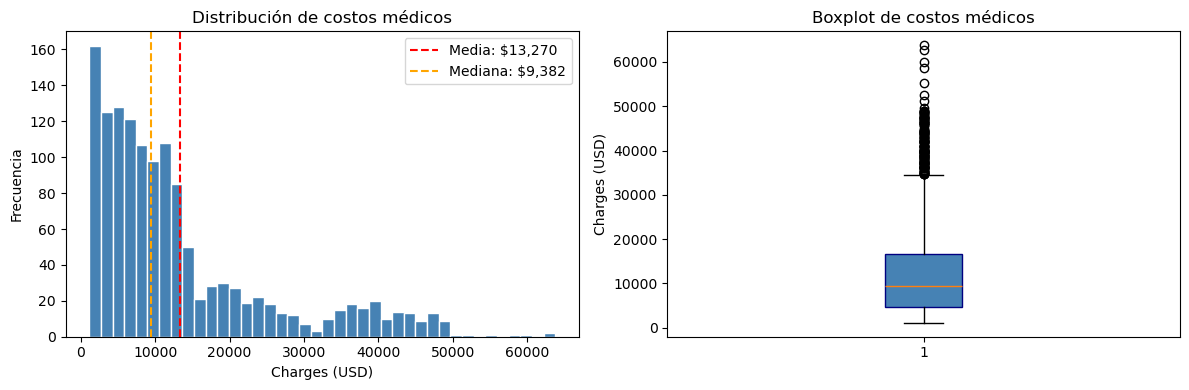

In [18]:
import matplotlib.pyplot as plt

media    = df["charges"].mean()
mediana  = df["charges"].median()
std      = df["charges"].std()
p25      = df["charges"].quantile(0.25)
p75      = df["charges"].quantile(0.75)

print(f"Media:    ${media:,.2f}")
print(f"Mediana:  ${mediana:,.2f}")
print(f"Desv. estándar: ${std:,.2f}")
print(f"P25: ${p25:,.2f}  |  P75: ${p75:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["charges"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(media,   color="red",    linestyle="--", label=f"Media: ${media:,.0f}")
axes[0].axvline(mediana, color="orange", linestyle="--", label=f"Mediana: ${mediana:,.0f}")
axes[0].set_title("Distribución de costos médicos")
axes[0].set_xlabel("Charges (USD)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

axes[1].boxplot(df["charges"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", color="navy"))
axes[1].set_title("Boxplot de costos médicos")
axes[1].set_ylabel("Charges (USD)")

plt.tight_layout()
plt.show()